In [ ]:
import os
import sys
import tensorflow as tf
from tensorflow import keras
from keras import layers

sys.path.insert(0, "code")
from visualization import (
    image_sample_by_class,
    distribution,
    confusion_matrices,
    classification_error_examples,
    error_confidence,
    )


print(sys.executable)
# sys.executable = "./scripts/tf_gpu_env.fish
print("LD_LIBRARY_PATH contains nvidia:", "site-packages/nvidia" in os.environ.get("LD_LIBRARY_PATH",""))

USE_GPU = True
CLASS_NAMES = ['avion','auto','oiseau','chat','cerf',
               'chien','grenouille','cheval','navire','camion']
               
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "0"
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)
if not gpus and USE_GPU:
    raise RuntimeError("No GPU detected by TensorFlow. Refusing CPU fallback.")
else:
    tf.config.set_visible_devices(gpus[0], "GPU")
    tf.config.experimental.set_memory_growth(gpus[0], True)


I0000 00:00:1775660581.973940 3704110 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775660582.078505 3704110 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775660583.091137 3704110 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


ModuleNotFoundError: No module named 'visualization'

In [ ]:

# Notebook  : Réseaux de Neurones Convolutionnels (CNN) pour la Classification d’Images



# Charger le dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalisation des images
x_train, x_test = x_train / 255.0, x_test / 255.0

# Définition du modèle CNN
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_test, y_test))

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)

y_proba = model.predict(x_test)

# Question pour expérimenter l'Apprentissage par Transfert




/home/kilo/Work/Cours - UQO/concept-statistique/concept-stat-projet-1/.venv-stat/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")
/home/kilo/Work/Cours - UQO/concept-statistique/concept-stat-projet-1/.venv-stat/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775618208.496616 2256862 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15443__.39


1523/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step - accuracy: 0.3492 - loss: 1.7530

I0000 00:00:1775618210.222832 2256858 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15443__.39


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4462 - loss: 1.5110 - val_accuracy: 0.5638 - val_loss: 1.2433
313/313 - 0s - 584us/step - accuracy: 0.5638 - loss: 1.2433
Précision sur l’ensemble de test : 0.5638


Exemples d'images CIFAR-10 par classe

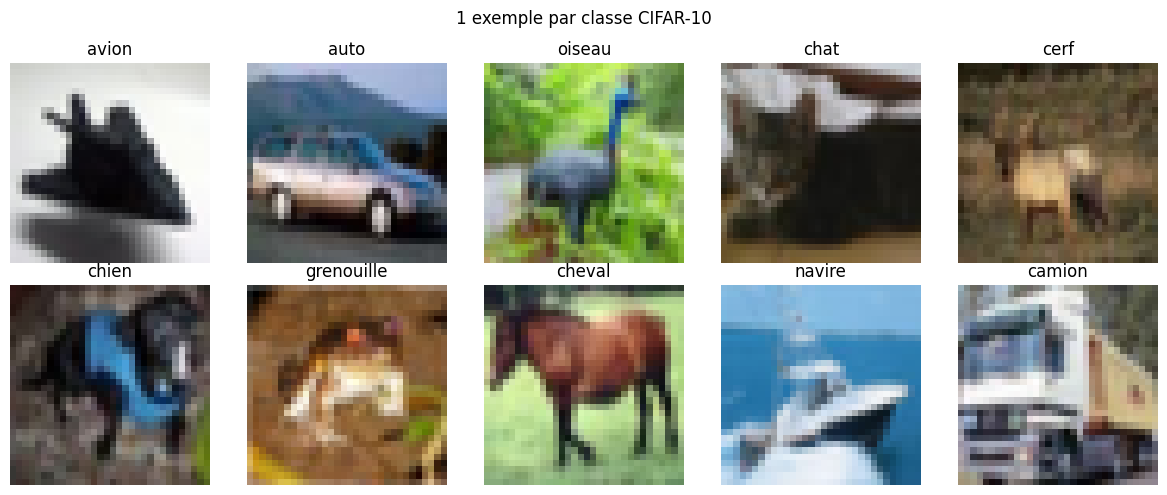

In [ ]:
image_sample_by_class(x_train, y_train)
distribution(y_train, y_test)
confusion_matrices(y_pred, y_test)
classification_error_examples(y_pred, x_test, y_test)
error_confidence(y_proba, y_pred, y_test)


Distribution des classes (train + test)

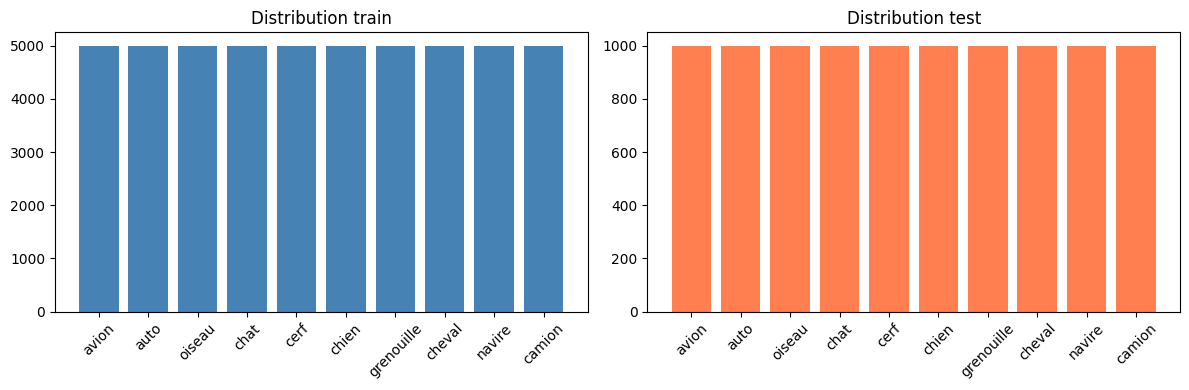

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(CLASS_NAMES, np.bincount(y_train.flatten()), color='steelblue')
ax1.set_title("Distribution train")
ax1.tick_params(axis='x', rotation=45)

ax2.bar(CLASS_NAMES, np.bincount(y_test.flatten()), color='coral')
ax2.set_title("Distribution test")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Matrice de confusion du modèle de base

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


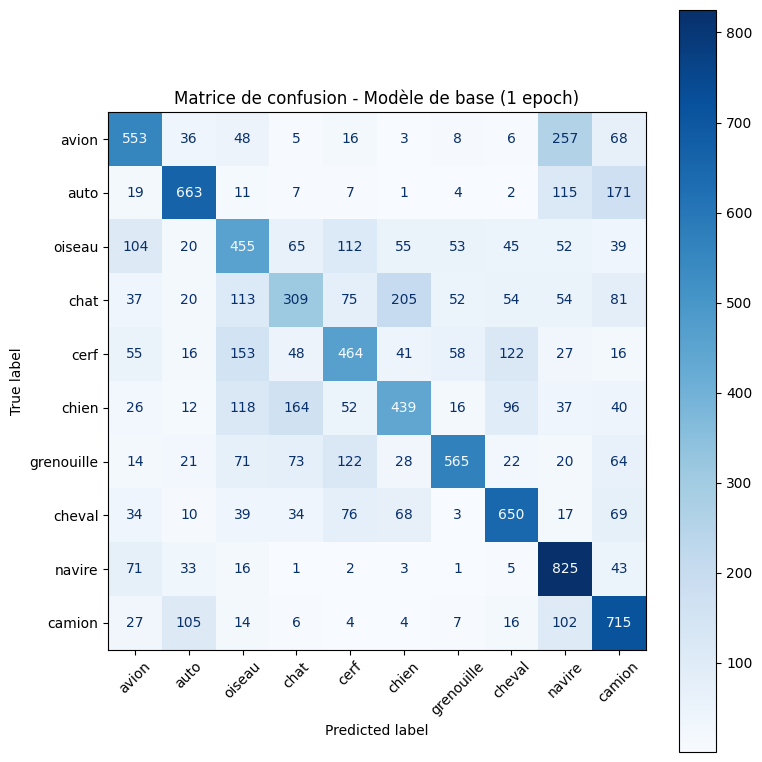

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test.flatten(), y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, values_format='d')
ax.set_title("Matrice de confusion - Modèle de base (1 epoch)")
plt.tight_layout()
plt.show()

Exemples d\'erreurs de classification

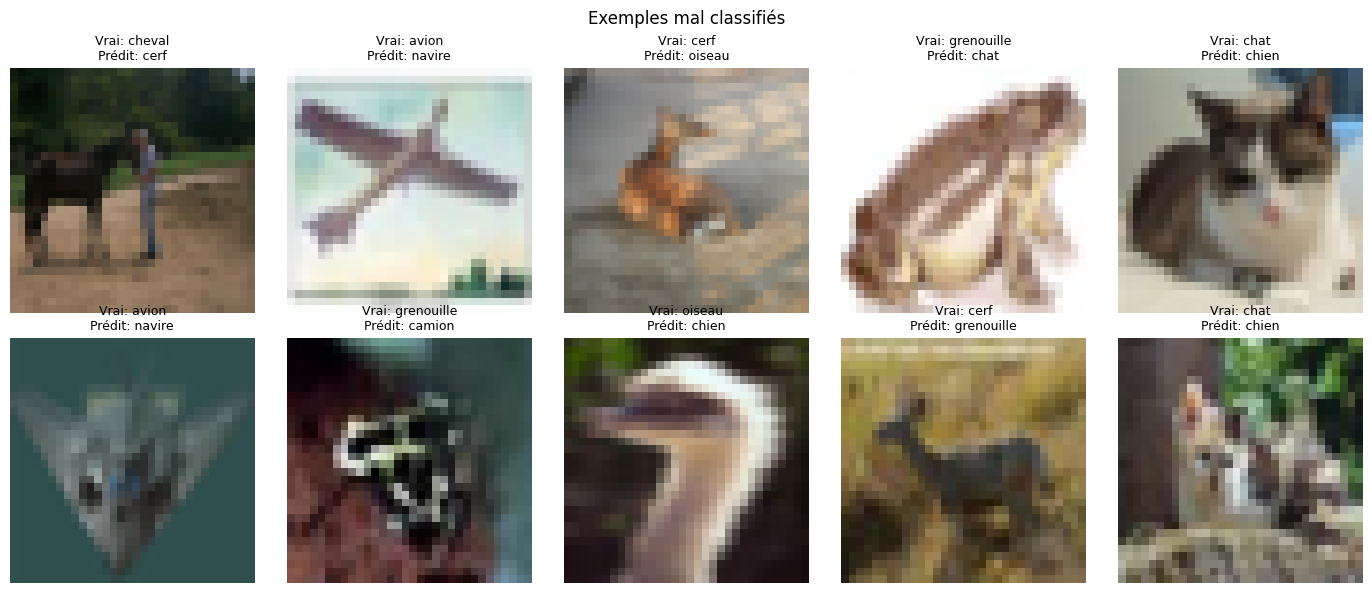

In [ ]:
errors = np.where(y_pred != y_test.flatten())[0]
sample = np.random.choice(errors, 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, idx in zip(axes.flat, sample):
    ax.imshow(x_test[idx])
    ax.set_title(f"Vrai: {CLASS_NAMES[y_test[idx,0]]}\nPrédit: {CLASS_NAMES[y_pred[idx]]}", fontsize=9)
    ax.axis('off')
fig.suptitle("Exemples mal classifiés")
plt.tight_layout()
plt.show()


Confiance du modèle sur les erreurs

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 398us/step


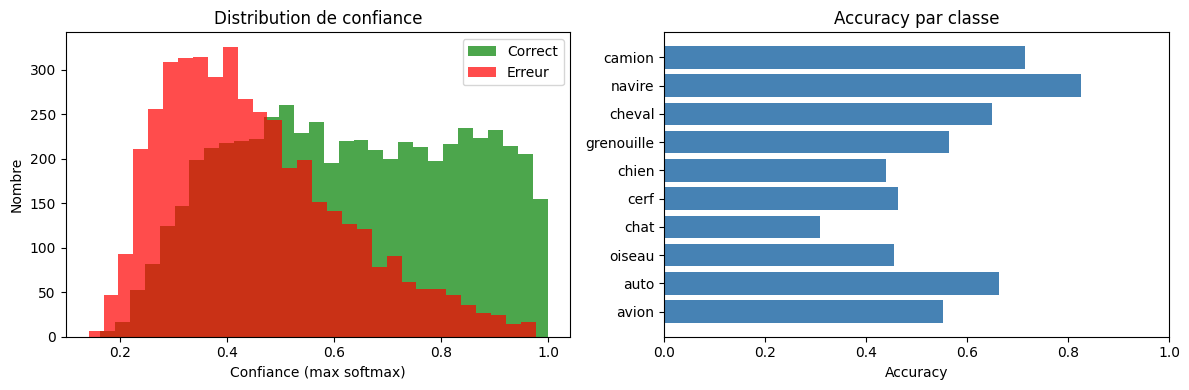

In [ ]:
y_proba = model.predict(x_test)
confidence = y_proba.max(axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

correct = y_pred == y_test.flatten()
ax1.hist(confidence[correct], bins=30, alpha=0.7, label='Correct', color='green')
ax1.hist(confidence[~correct], bins=30, alpha=0.7, label='Erreur', color='red')
ax1.set_xlabel('Confiance (max softmax)')
ax1.set_ylabel('Nombre')
ax1.set_title('Distribution de confiance')
ax1.legend()

# Accuracy par classe
acc_per_class = cm.diagonal() / cm.sum(axis=1)
ax2.barh(CLASS_NAMES, acc_per_class, color='steelblue')
ax2.set_xlim(0, 1)
ax2.set_xlabel('Accuracy')
ax2.set_title('Accuracy par classe')

plt.tight_layout()
plt.show()

In [ ]:
# Charger le modèle pré-entraîné  VGG16
base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # Geler les poids du modèle pré-entraîné

# Ajouter une couche de classification personnalisée
transfer_model = keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compilation et entraînement du modèle avec transfert d’apprentissage
transfer_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Entraînement rapide pour test
transfer_model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_test, y_test))

# Comparer la performance avec et sans transfert d’apprentissage
test_loss_transfer, test_acc_transfer = transfer_model.evaluate(x_test, y_test, verbose=2)
print(f'Précision avec apprentissage par transfert : {test_acc_transfer:.4f}')

NameError: name 'applications' is not defined